# Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))
# 
# Enable autoreload for Jupyter notebooks
%load_ext autoreload
%autoreload 2

from paths import DATA_DATASETS, DATA_EMBEDDINGS
from helper_functions import plot_2d_projection, apply_umap, generate_cluster_names

Failed to read module file 'C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 

# Load Data

In [2]:
outfits = pd.read_csv(DATA_DATASETS / "outfits.csv", sep=";")
embeddings = pd.read_csv(DATA_EMBEDDINGS / "embeddings_voyage_multimodal.csv", sep=";")
transactions = pd.read_csv(DATA_DATASETS / "transactions.csv", sep=";")

outfits = outfits.rename(columns={"id": "outfit.id"})

# Join outfits with embeddings
data = outfits.merge(embeddings, left_on="outfit.id", right_on="outfit_id")

# Extract embedding features
embedding_cols = [col for col in data.columns if col.startswith("dim_")]
X = data[embedding_cols].values

Compute a 2D UMAP embedding of the high-dimensional feature matrix X for visualization.
The embedding is calculated once and reused to avoid repeated expensive computations.

In [3]:
X_2d = apply_umap(embedding_matrix = X, n_components=2)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dimension reduction with UMAP to 20 dimensions to confirm that 2048 dimensions is too much to form robust clusters (Curse of dimensionality) with the K-Means algorithm. 

In [4]:
X_reduced = apply_umap(embedding_matrix = X, n_components=20)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [5]:
kmeans = KMeans(n_clusters=8, random_state=42)

data["cluster"] = kmeans.fit_predict(X_reduced)

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_15288\1500716983.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["cluster"] = kmeans.fit_predict(X_reduced)


In [6]:
# 1. Generate the naming dictionary
# (Make sure 'category_name' matches the actual column name in your dataset)
cluster_mapping = generate_cluster_names(data, cluster_col='cluster', feature_col='Category', top_n=2)

# 2. Apply the dictionary to create a new, readable column for your business analysis
data['cluster_name'] = data['cluster'].map(cluster_mapping)

Cluster 0 contains mainly: Bags & Accessories
Cluster 1 contains mainly: Tops & Blouses
Cluster 2 contains mainly: Dresses & Jumpsuits
Cluster 3 contains mainly: Sweaters & Knitwear
Cluster 4 contains mainly: Jewelry & Accessories
Cluster 5 contains mainly: Trousers & Shorts
Cluster 6 contains mainly: Skirts & Knitwear
Cluster 7 contains mainly: Jackets & Coats


C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_15288\522886945.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['cluster_name'] = data['cluster'].map(cluster_mapping)


In [7]:
# cluster_names = {   0: "Iconic Arm Candy", 
#                     1: "Blouses & Shirts", 
#                     2: "Dress", 
#                     3: "Nordic Comfort", 
#                     4: "Golden Hour Details", 
#                     5: "Trousers", 
#                     6: "Skirts", 
#                     7: "Jackets & Coats" }

# data["cluster_name"] = data["cluster"].map(cluster_names)

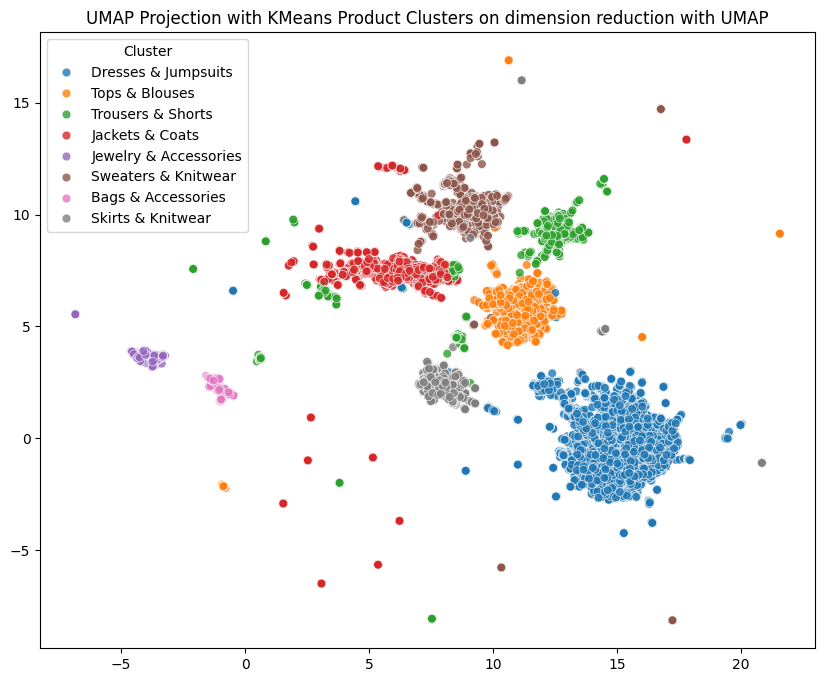

In [8]:
plot_2d_projection(X_2d = X_2d, # Use 2D UMAP projection for visualization
                   labels = data["cluster_name"], 
                   title = "UMAP Projection with KMeans Product Clusters on dimension reduction with UMAP")

### Cluster Label Export

In [9]:
# Export cluster labels for Assignment 2 & 3
cluster_export = data[["outfit.id", "cluster", "cluster_name"]].copy()
cluster_export.to_csv(DATA_DATASETS / "outfits_clusters_labels.csv", index=False, sep=";")

print(cluster_export["cluster_name"].value_counts())

cluster_name
Dresses & Jumpsuits      6623
Tops & Blouses           2168
Jackets & Coats          1911
Sweaters & Knitwear      1704
Trousers & Shorts        1409
Skirts & Knitwear        1090
Bags & Accessories        421
Jewelry & Accessories     323
Name: count, dtype: int64


# Business Profiling

## Retail price
Price the rental company has to buy the clothes at

In [10]:
price_profile = data.groupby("cluster")["retailPrice"].agg([
    "mean", "median", "min", "max", "count"
]).sort_values("mean", ascending=False)

price_profile.round(2) # Prices are in NOK - 1000 NOK ~ 80 CHF ~ 90 Euro

,mean,median,min,max,count
cluster,,,,,
0,6804.81,4000.0,0.0,52800.0,353
7,3937.86,3200.0,0.0,45000.0,1827
2,2801.97,2400.0,0.0,80000.0,5815
5,2118.70,1725.0,500.0,21000.0,1364
3,2113.63,1900.0,0.0,11500.0,1679
6,2032.77,1700.0,400.0,59400.0,1042
1,1769.23,1500.0,266.0,12500.0,2103
4,1674.18,1500.0,200.0,15000.0,306


## Rental prices for segments 

In [11]:
revenue_profile_month = data.groupby("cluster")["pricePerMonth"].agg(["mean", "median", "count"])
revenue_profile_week = data.groupby("cluster")["pricePerWeek"].agg(["mean", "median"])

revenue_profile_month.columns = [" Month Mean (NOK)", " Month Median (NOK)", "Number of Items"]
revenue_profile_week.columns = [" Week Mean (NOK)", " Week Median (NOK)"]

revenue_profile_week = revenue_profile_week.round(2).sort_values(by=" Week Median (NOK)", ascending=False)

revenue_profile = revenue_profile_week.join(revenue_profile_month)

revenue_profile

,Week Mean (NOK),Week Median (NOK),Month Mean (NOK),Month Median (NOK),Number of Items
cluster,,,,,
7,810.87,900.0,1605.735217,1800.0,1911
0,743.36,690.0,1498.432304,1300.0,421
2,679.36,600.0,1306.138608,1200.0,6623
1,599.22,590.0,1184.154059,1180.0,2168
3,663.00,590.0,1318.776995,1180.0,1704
4,562.09,590.0,1115.882353,1180.0,323
5,635.98,590.0,1262.184528,1180.0,1409
6,589.17,590.0,1156.174312,1180.0,1090


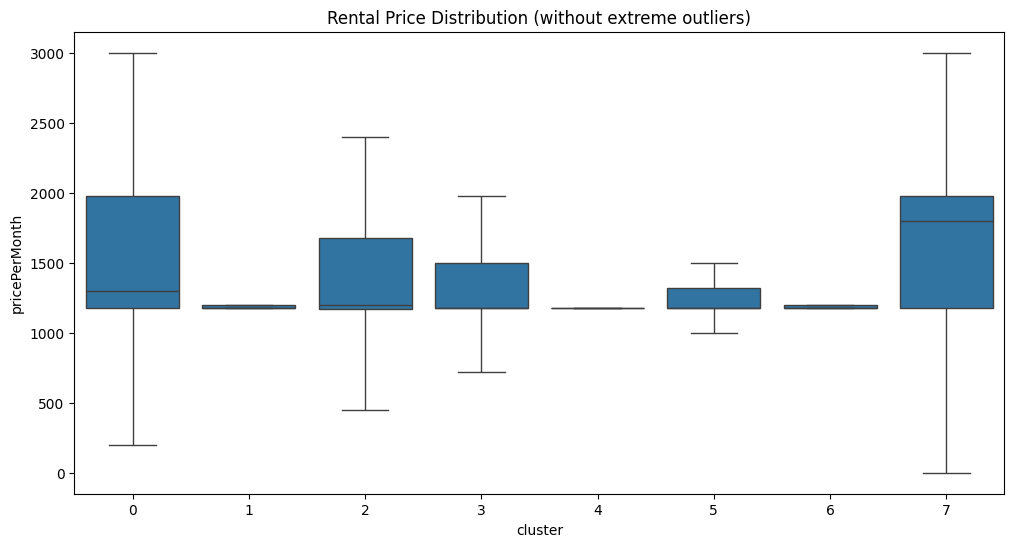

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data, x="cluster", y="pricePerMonth", showfliers=False)

plt.title("Rental Price Distribution (without extreme outliers)")
plt.show()

In [13]:
# 1. Check how many items have pricePerMonth == exactly the same value
print(data["pricePerMonth"].value_counts().head(20))

# 2. Check the distribution shape overall
print(data["pricePerMonth"].describe())

# 3. Check if missing/null prices were filled with a default value
print("Nulls in pricePerMonth:", data["pricePerMonth"].isna().sum())
print("Zeros:", (data["pricePerMonth"] == 0).sum())

# 4. Check specifically the flat clusters
for c in range(0, 8):
    vals = data[data["cluster"] == c]["pricePerMonth"]
    print(f"\nCluster {c}: n={len(vals)}, unique prices={vals.nunique()}, median={vals.median()}")

pricePerMonth
1180.0    5331
1980.0    2408
1200.0     955
1500.0     851
1800.0     506
600.0      401
1320.0     371
1680.0     324
400.0      303
500.0      292
1440.0     268
1560.0     260
900.0      251
800.0      240
1380.0     224
700.0      192
1260.0     191
1620.0     184
1740.0     169
300.0      145
Name: count, dtype: int64
count    15649.000000
mean      1314.044092
std        461.288772
min          0.000000
25%       1180.000000
50%       1180.000000
75%       1620.000000
max      10500.000000
Name: pricePerMonth, dtype: float64
Nulls in pricePerMonth: 0
Zeros: 10

Cluster 0: n=421, unique prices=51, median=1300.0

Cluster 1: n=2168, unique prices=48, median=1180.0

Cluster 2: n=6623, unique prices=83, median=1200.0

Cluster 3: n=1704, unique prices=44, median=1180.0

Cluster 4: n=323, unique prices=26, median=1180.0

Cluster 5: n=1409, unique prices=47, median=1180.0

Cluster 6: n=1090, unique prices=43, median=1180.0

Cluster 7: n=1911, unique prices=55, median=1800.

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_15288\2850952111.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["price_tier"] = np.where(data["pricePerMonth"] <= 1180, "Floor (≤1180 NOK)", "Above Floor")


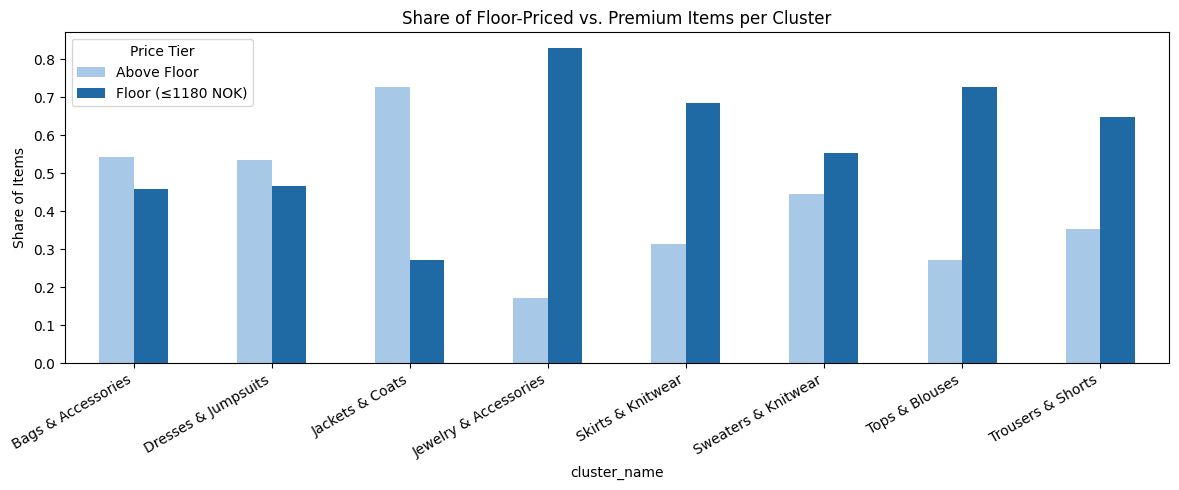

In [14]:
# Split items into floor-priced vs. above-floor
data["price_tier"] = np.where(data["pricePerMonth"] <= 1180, "Floor (≤1180 NOK)", "Above Floor")

# Show composition per cluster
tier_pct = data.groupby(["cluster_name", "price_tier"]).size().unstack(fill_value=0)
tier_pct = tier_pct.div(tier_pct.sum(axis=1), axis=0)

tier_pct.plot(kind="bar", figsize=(12, 5), color=["#a8c8e8", "#1f6aa5"])
plt.title("Share of Floor-Priced vs. Premium Items per Cluster")
plt.ylabel("Share of Items")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Price Tier")
plt.tight_layout()
plt.show()

In [15]:
data_premium = data[data["pricePerMonth"] > 1180]
premium_profile = data_premium.groupby("cluster_name")["pricePerMonth"].agg(["mean", "median", "count"])
print(premium_profile.sort_values("median", ascending=False).round(2))

                          mean  median  count
cluster_name                                 
Bags & Accessories     1953.95  1980.0    228
Jackets & Coats        1838.30  1980.0   1391
Dresses & Jumpsuits    1639.49  1620.0   3538
Sweaters & Knitwear    1593.13  1560.0    760
Jewelry & Accessories  1612.18  1500.0     55
Tops & Blouses         1542.38  1500.0    590
Trousers & Shorts      1598.95  1500.0    497
Skirts & Knitwear      1532.72  1440.0    342


Vibrent's pricing is heavily discretized into a small number of fixed tiers (300, 400, 500, 600, 700, 800, 900, 1180, 1200, 1320... NOK), with 1,180 NOK being the most common tier by far, accounting for 34% of items. This suggests a structured pricing policy rather than item-by-item price setting. Most garments get assigned to a standard tier, with exceptions for very cheap accessories or very high-end pieces. 

Clusters with a median at exactly 1,180 NOK (Tops, Knitwear, Trousers, Skirts, Jewelry) are commoditized within Vibrent's pricing structure, while Jackets & Coats (1,800 NOK) and Bags & Accessories (1,300 NOK) command meaningfully above-standard rental prices.

## Cluster revenue

In [16]:
rentals = transactions.merge(
    data[["outfit.id", "cluster", "pricePerWeek", "pricePerMonth"]],
    left_on="outfit.id",
    right_on="outfit.id",
    how="left"
)

Calculate rental duration/period

In [17]:
rentals["duration_days"] = (
    pd.to_datetime(rentals["rentalPeriod.end"]) -
    pd.to_datetime(rentals["rentalPeriod.start"])
).dt.days

In [18]:
negative = rentals[rentals["duration_days"] < 0]
zero = rentals[rentals["duration_days"] == 0]

print(f"Number of negative duration rentals: {len(negative)}")
print(f"Share of total: {len(negative)/len(rentals)*100:.2f}%")
print(f"Zero duration rentals: {len(zero)}")
print(f"Share of total: {len(zero)/len(rentals)*100:.2f}%")

Number of negative duration rentals: 7
Share of total: 0.01%
Zero duration rentals: 53
Share of total: 0.09%


Clean data from invalid rentals durations and prices

In [19]:
rentals_clean = rentals[
    (rentals["duration_days"] > 0) &
    (
        (rentals["duration_days"] <= 7) & rentals["pricePerWeek"].notna() |
        (rentals["duration_days"] > 7) & rentals["pricePerMonth"].notna()
    )
].copy()

Data cleaning removed 60 transactions with invalid rental durations (7 with negative duration caused by swapped start/end dates, all from 2017–2018, and 53 zero-duration entries), representing 0.1% of the dataset. No systematic pattern was identified and the records were dropped prior to analysis.

In [20]:
# Overall duration distribution
print("=== Overall Rental Duration (days) ===")
print(rentals_clean["duration_days"].describe().round(1))

print("\nDuration buckets:")
bins   = [-1, 7, 14, 30, 90, 9999]
labels = ["≤7d (weekly)", "8–14d", "15–30d", "31–90d", ">90d"]
rentals_clean["duration_bucket"] = pd.cut(rentals_clean["duration_days"], bins=bins, labels=labels)
print(rentals_clean["duration_bucket"].value_counts().sort_index())

=== Overall Rental Duration (days) ===
count    60897.0
mean        26.3
std         13.6
min          1.0
25%         27.0
50%         29.0
75%         30.0
max        395.0
Name: duration_days, dtype: float64

Duration buckets:
duration_bucket
≤7d (weekly)     9724
8–14d            1743
15–30d          39582
31–90d           9546
>90d              302
Name: count, dtype: int64


In [21]:
# Assignment states: Customer revenue in the prediction period is derived from rental transactions using 
# these standard rental prices. Rentals of up to 7 days are billed at the weekly rate, while 
# longer rentals are calculated proportionally using the monthly rate. 

rentals_clean["revenue"] = np.where(
    rentals_clean["duration_days"] <= 7, # 1 week or less -> weekly price
    rentals_clean["pricePerWeek"],
    rentals_clean["pricePerMonth"] * rentals_clean["duration_days"] / 30 # Pro-rated monthly price based on actual duration
)

In [22]:
rentals_clean.head()

,customer.id,outfit.id,rentalPeriod.start,rentalPeriod.end,cluster,pricePerWeek,pricePerMonth,duration_days,duration_bucket,revenue
0,3448,outfit.5c081909537b42239e465d2d615c705f,2023-03-26,2023-04-25,3.0,750.0,1500.0,30,15–30d,1500.000000
1,2924,outfit.c34969dd8b334064aa90bfb60c8ec308,2023-03-27,2023-04-26,7.0,990.0,1980.0,30,15–30d,1980.000000
2,2924,outfit.aef4cc93eebf40ca8820790deb7a8323,2023-01-27,2023-02-26,3.0,840.0,1680.0,30,15–30d,1680.000000
3,1128,outfit.3de5df48a14b4a9aba6d8e41d11e9351,2021-11-16,2021-12-15,7.0,990.0,1980.0,29,15–30d,1914.000000
4,1128,outfit.0eaa358af14e469894062591bd42f38b,2021-10-11,2021-11-11,1.0,590.0,1180.0,31,31–90d,1219.333333


In [23]:
# Export cluster labels for Assignment 2 & 3
transactions_export = rentals_clean[["customer.id", "rentalPeriod.start", "revenue"]].copy()
transactions_export = transactions_export.rename(columns={
    "rentalPeriod.start": "date"
})

transactions_export.to_csv(DATA_DATASETS / "transactions_processed.csv", index=False, sep=";")

In [24]:
cluster_revenue = rentals_clean.groupby("cluster")["revenue"].agg([
    "sum", "mean", "count"
]).sort_values("sum", ascending=False)

cluster_revenue

,sum,mean,count
cluster,,,
2.0,3.441582e+07,1265.520217,27195
7.0,1.297092e+07,1759.007413,7374
1.0,1.073672e+07,1248.890915,8597
3.0,9.164850e+06,1393.469647,6577
5.0,5.308089e+06,1352.379278,3925
0.0,4.261118e+06,1439.567005,2960
6.0,4.019336e+06,1268.729798,3168
4.0,1.290451e+06,1172.072056,1101


## Customer revenue

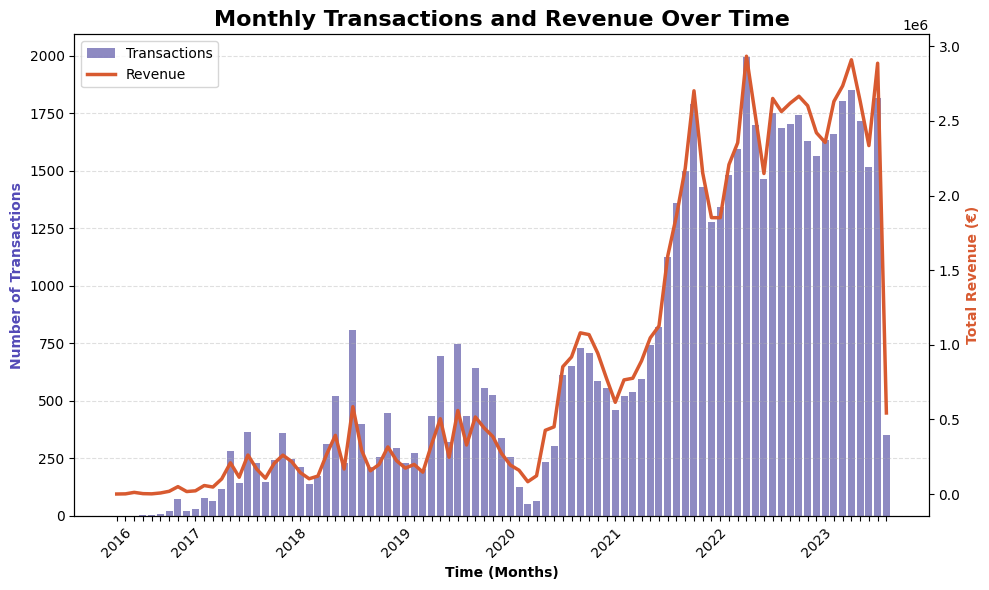

In [38]:
# --- SETUP: Replace these with your actual column names ---
# df = your_dataframe
# date_col = 'created_at'  # The column containing the transaction date
# revenue_col = 'price'    # The column containing the revenue/price
# id_col = 'order_id'      # A unique ID to count transactions
# ---------------------------------------------------------

# 1. Ensure the date column is actually a datetime object
transactions_export["date"] = pd.to_datetime(transactions_export["date"])

# 2. Aggregate the data (e.g., by Month)
# We group by the Year-Month to get a clean timeline
monthly_data = transactions_export.groupby(transactions_export["date"].dt.to_period('M')).agg(
    total_transactions=("revenue", 'count'),
    total_revenue=("revenue", 'sum')
).reset_index()

# Convert the Period object back to a string/timestamp for plotting
monthly_data["date"] = monthly_data["date"].dt.to_timestamp()

# 3. Create the Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Transactions as Bar Chart (Left Y-Axis)
sns.barplot(
    data=monthly_data, 
    x="date", 
    y='total_transactions', 
    color="#534AB7", 
    alpha=0.7, 
    ax=ax1,
    label='Transactions'
)

ax1.set_xlabel('Time (Months)', fontweight='bold')
ax1.set_ylabel('Number of Transactions', color="#534AB7", fontweight='bold')
ax1.tick_params(axis='y')

x_dates = monthly_data["date"].dt.strftime('%Y-%m')
clean_labels = []

for i, date_str in enumerate(x_dates):
    year, month = date_str.split('-')
    # Only show the year if it's January OR if it's the very first data point on the chart
    if month == '01' or i == 0:
        clean_labels.append(year)
    else:
        clean_labels.append('') # Leave the rest blank for a clean look

ax1.set_xticks(range(len(x_dates)))
ax1.set_xticklabels(clean_labels, rotation=45, ha='center') # Set rotation to 0 since years fit nicely


# Plot 2: Revenue as Line Chart (Right Y-Axis)
ax2 = ax1.twinx()  # Create a second y-axis that shares the same x-axis
sns.lineplot(
    data=monthly_data, 
    x=ax1.get_xticks(), # Align line plot with bar plot x-coordinates
    y='total_revenue', 
    color="#D85A30",
    linewidth=2.5,
    ax=ax2,
    label='Revenue'
)

ax2.set_ylabel('Total Revenue (€)', color="#D85A30", fontweight='bold')
ax2.tick_params(axis='y')

# Final Touches: Title and Grid
plt.title('Monthly Transactions and Revenue Over Time', fontsize=16, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Remove Seaborn's automatic legends if they exist
if ax1.get_legend():
    ax1.get_legend().remove()
if ax2.get_legend():
    ax2.get_legend().remove()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
customer_revenue = rentals_clean.groupby("customer.id")["revenue"].sum()

Customer Cluster Affinity

In [ ]:
customer_cluster_revenue = rentals_clean.groupby(
    ["customer.id", "cluster"]
)["revenue"].sum().unstack(fill_value=0)

customer_cluster_revenue.head()

Value Mapping: Cash Cow vs. High End

In [ ]:
cluster_economics = (
    rentals_clean
    .merge(data[["outfit.id", "cluster_name"]], on="outfit.id")
    .groupby("cluster_name")
    .agg(
        revenue=("revenue", "sum"),
        rental_volume=("outfit.id", "count"),
        avg_price=("pricePerWeek", "mean")
    )
)

# Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(data=cluster_economics, x="rental_volume", y="avg_price", size="revenue", sizes=(100, 1000), hue=cluster_economics.index)
plt.title("Value Mapping: Volume vs. Price (Size = Total Revenue)")
plt.xlabel("Number of Rentals (Volume)")
plt.ylabel("Average Price per Week (€)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
cluster_economics.sort_values("revenue", ascending=False).round(2)

## Customer Affinity Analysis

In [ ]:
# Define a loyal vs. at-risk customer based on recency
CUTOFF = pd.Timestamp("2023-09-05") # Last date in the dataset is 2023-09-05

transactions["rentalPeriod.start"] = pd.to_datetime(transactions["rentalPeriod.start"])

last_rental = transactions.groupby("customer.id")["rentalPeriod.start"].max() # Get the most recent rental date for each customer

recency_days = (CUTOFF - last_rental).dt.days # Calculate recency in days for each customer

# Loyal = rented in last 180 days before cutoff; At-risk = more than 365 days ago
customer_loyalty = pd.cut(
    recency_days,
    bins=[-1, 180, 365, 99999],
    labels=["Loyal", "Dormant", "At-Risk"]
)
customer_loyalty = customer_loyalty.rename("loyalty_segment")

In [ ]:
# Compute each customer's cluster affinity (share of rentals per cluster)
# How much of each customer's spending went into each style cluster?

customer_cluster_pct = customer_cluster_revenue.div(
    customer_cluster_revenue.sum(axis=1), axis=0
)

# Add loyalty label
customer_cluster_pct = customer_cluster_pct.join(customer_loyalty)
customer_cluster_pct = customer_cluster_pct.dropna(subset=["loyalty_segment"])

In [ ]:
# Plot - Average cluster affinity by loyalty segment
affinity_by_loyalty = customer_cluster_pct.groupby("loyalty_segment").mean()

# Map cluster numbers to names for readability
affinity_by_loyalty.columns = [
    data.set_index("cluster")["cluster_name"].drop_duplicates().to_dict().get(c, c)
    for c in affinity_by_loyalty.columns
]

affinity_by_loyalty.T.plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Average Style Cluster Affinity by Customer Loyalty Segment")
plt.ylabel("Share of Total Spending")
plt.xlabel("Product Cluster")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Loyalty Segment")
plt.tight_layout()
plt.show()

In [ ]:
affinity_by_loyalty 

In [ ]:
# Average total revenue by loyalty segment
revenue_by_loyalty = customer_revenue.rename("total_revenue").to_frame().join(customer_loyalty)
revenue_by_loyalty.groupby("loyalty_segment")["total_revenue"].agg(["mean", "median", "count"]).round(2)

## Assortment Strategy

White Spaces: Utilization - Identifying where demand exceeds supply

In [ ]:
# 1. Count items in inventory per cluster
inventory_count = data.groupby("cluster_name")["outfit.id"].count()

# 2. Count rentals per cluster
rental_count = (
    rentals_clean
    .merge(data, left_on="outfit.id", right_on="outfit.id")
    .groupby("cluster_name")["outfit.id"]
    .count()
)

# 3. Calculate Utilization (Rentals per Item)
utilization = pd.DataFrame({"Inventory": inventory_count, "Rentals": rental_count})
utilization["Utilization_Rate"] = utilization["Rentals"] / utilization["Inventory"]

# Sort and visualize
utilization.sort_values("Utilization_Rate", ascending=False).plot(kind="bar", y="Utilization_Rate", color="teal", figsize=(10,5))
plt.title("Assortment Efficiency: Which clusters are working the hardest?")
plt.ylabel("Avg Rentals per Item")
plt.show()

In [ ]:
print(utilization["Utilization_Rate"].mean())

utilization.sort_values("Utilization_Rate", ascending=False)

## Renting Duration

In [ ]:
# Duration by cluster
duration_by_cluster = rentals_clean.merge(
    data[["outfit.id", "cluster_name"]], left_on="outfit.id", right_on="outfit.id"
).groupby("cluster_name")["duration_days"].agg(["mean", "median", "std"]).round(1)

duration_by_cluster.sort_values("median", ascending=False)

In [ ]:
# Most rented individual items
item_rentals = rentals_clean.groupby("outfit.id").agg(
    n_rentals        = ("customer.id", "count"),
    unique_customers = ("customer.id", "nunique"),
    avg_duration     = ("duration_days", "mean"),
    total_revenue    = ("revenue", "sum")
).reset_index()

# Join outfit metadata
item_rentals = item_rentals.merge(
    data[["outfit.id", "name", "cluster_name", "retailPrice", "pricePerMonth"]],
    left_on="outfit.id", right_on="outfit.id", how="left"
)

print("=== Top 20 most rented items ===")
print(item_rentals.sort_values("n_rentals", ascending=False).head(20)[
    ["name", "cluster_name", "n_rentals", "unique_customers", "avg_duration", "total_revenue"]
].to_string())

In [ ]:
# Never-rented items
all_outfit_ids  = set(data["outfit.id"])
rented_ids      = set(rentals_clean["outfit.id"].dropna())
never_rented    = all_outfit_ids - rented_ids

never_rented_df = data[data["outfit.id"].isin(never_rented)][
    ["outfit.id", "name", "cluster_name", "retailPrice", "pricePerMonth"]
]

print(f"Total outfits in catalog:  {len(all_outfit_ids)}")
print(f"Ever rented:               {len(rented_ids)}")
print(f"Never rented:              {len(never_rented_df)} ({len(never_rented_df)/len(all_outfit_ids)*100:.1f}%)")

print("\n=== Never-rented items by cluster ===")
print(never_rented_df["cluster_name"].value_counts())

print("\n=== Never-rented share per cluster ===")
total_per_cluster  = data["cluster_name"].value_counts()
never_per_cluster  = never_rented_df["cluster_name"].value_counts()
share = (never_per_cluster / total_per_cluster * 100).round(1).sort_values(ascending=False)
print(share)

In [ ]:
# Check rentals per item  
print("Items rented only once:", (item_rentals["n_rentals"] == 1).sum())
print("Items rented 2–5 times:", item_rentals["n_rentals"].between(2, 5).sum())
print("Items rented 6-20 times:", item_rentals["n_rentals"].between(6, 20).sum())
print("Items rented >20 times:", (item_rentals["n_rentals"] > 20).sum())

# Workhorses: items rented by many different customers
print("\n=== Top 10 items by unique customers ===")
print(item_rentals.sort_values("unique_customers", ascending=False).head()[
    ["name", "cluster_name", "n_rentals", "unique_customers", "total_revenue"]
].to_string())

Five clusters show a median rental duration of exactly 30 days with low variance, indicating standardized monthly billing behavior. Bags & Accessories is the outlier with a mean of 21.4 days and the highest standard deviation (17.4), reflecting a mix of short event rentals and monthly holds. At the item level, 31.2% of the catalog has never been rented, with the largest absolute dead inventory in Dresses (2,099 items) but the highest never-rented share in Jackets & Coats (36.7%) and Trousers (35.8%). Bags again performs best with only 20% never-rented items. The top 20 most rented items are split between Bags (8 items) and Dresses (9 items), with individual bag items generating on average 44% more total revenue than comparable dress items.

## Business Insights from Product Segmentation

Combining the pricing structure, revenue contribution, and utilization data across the eight product clusters reveals three distinct strategic roles within Vibrent's catalog, and one clear growth opportunity:

**The Revenue Engine: Dresses & Jumpsuits**

Dresses & Jumpsuits is the undisputed core of the business. The cluster accounts for 41.9% of total revenue while holding 42.3% of inventory — a near-perfect match that indicates Vibrent has correctly sized this category relative to demand. Its utilization rate of 4.1 rentals per item confirms healthy throughput, and its median rental price of 1,200 NOK sits just above the standard tier. However, the average weekly price of 738 NOK is the second lowest among all clusters, suggesting that volume rather than price premium is the growth driver here. Vibrent's strategy of keeping dress rentals accessible appears deliberate and well-calibrated.

**The Premium Anchor: Jackets & Coats**

Jackets & Coats is the highest-priced cluster with a median monthly rental of 1,800 NOK and an average weekly price of 869 NOK, generating 15.8% of total revenue from only 12.2% of inventory. Its revenue per inventory item of 6,790 NOK is the second highest in the catalog. The cluster punches above its inventory weight, confirming that premium outerwear commands both higher prices and strong demand — a combination that justifies continued investment in this category.

**The Hidden Opportunity: Bags & Accessories**

Bags & Accessories is the most compelling finding across all three analyses. With only 421 items — just 2.7% of total inventory — it generates 5.2% of revenue, yielding a revenue-per-item figure of 10,139 NOK, nearly double that of Dresses (5,201 NOK) and 49% higher than Jackets & Coats (6,790 NOK). Its utilization rate of 7.05 is 71% above the catalog average and nearly double that of Dresses. Despite commanding the second-highest average weekly price of 854 NOK, demand shows no sign of saturation. This combination — highest revenue efficiency, highest utilization, thin inventory — constitutes a clear supply-constrained white space. Expanding the bag inventory is the single highest-return assortment decision available to Vibrent.

**The Underperformers: Trousers, Skirts, and Jewelry**

Trousers & Shorts and Skirts & Knitwear are the weakest performers across all dimensions. Trousers hold 9.0% of inventory but generate only 6.5% of revenue, with the lowest utilization rate in the catalog at 2.79. Skirts follow a similar pattern: 7.0% of inventory for 4.9% of revenue and a utilization rate of 2.91. Both clusters are priced at the standard 1,180 NOK tier with below-average weekly prices (670 and 638 NOK respectively), and their revenue per item figures of 3,768 and 3,688 NOK are the lowest in the catalog. These categories attract the occasion-driven one-time renters identified in the customer affinity analysis — customers who rent once and do not return. Jewelry & Accessories, while small, also underperforms on revenue per item at 3,995 NOK despite moderate utilization. Taken together, these three clusters represent over-invested, under-performing inventory that should be reduced in favor of higher-efficiency categories.

**Summary**

Vibrent's assortment is well-balanced at its core — Dresses and Jackets are correctly sized and priced — but carries a structural inefficiency at both extremes. The catalog is simultaneously under-investing in Bags, where demand clearly exceeds supply, and over-investing in everyday basics like Trousers and Skirts, where rental demand is structurally weak. Reallocating even a portion of the basics inventory budget toward Bags & Accessories would improve both revenue efficiency and customer engagement metrics.

### Hypotheses

**Hypothesis 1 — Bags & Accessories are supply-constrained despite being the highest-demand category**

The utilization analysis reveals that Bags & Accessories has by far the highest rentals-per-item ratio in the catalog at 7.05. 71% above the catalog average and nearly double that of Dresses & Jumpsuits (4.11). Yet the cluster holds only 421 items, representing just 2.7% of total inventory. This supply constraint is further confirmed by the revenue-per-item figure of 10,139 NOK, which is nearly double the catalog's second-best performer (Jackets & Coats at 6,790 NOK). The combination of highest utilization, highest revenue efficiency, and thinnest inventory constitutes a clear white space: expanding bag inventory is the single highest-return assortment decision available to Vibrent.

**Hypothesis 2 — Occasion-driven styles generate engagement; everyday basics do not**

Clusters corresponding to everyday wear show substantially lower utilization rates than occasion-driven categories. Trousers & Shorts (2.79) and Skirts & Knitwear (2.91) are the two weakest performers in the catalog, while Dresses & Jumpsuits (4.11) and Jackets & Coats (3.86) maintain healthy throughput. This gap is further reflected in revenue efficiency: Trousers and Skirts generate the lowest revenue-per-item figures in the catalog at 3,768 and 3,688 NOK respectively, compared to 5,201 NOK for Dresses. This is consistent with Vibrent's rental model — customers pay to access items they would not buy outright for a single event, not to replace wardrobe staples they already own. Together, Trousers and Skirts hold 16% of total inventory but generate only 11.3% of revenue, representing a structural over-investment that should be reallocated toward higher-efficiency categories.

**Hypothesis 3 — Style diversity, not style preference, predicts customer loyalty**

The customer affinity analysis segments customers by rental recency and maps their spending across the eight style clusters. The results reveal a non-linear pattern that refines the original hypothesis. Loyal and Dormant customers are nearly indistinguishable in their style preferences — both allocate roughly 39% of spending to Dresses & Jumpsuits and distribute the remainder broadly across Tops (14.6%), Jackets (15.9%), and Knitwear (12.9%). At-Risk customers, by contrast, concentrate 79% of their spending on Dresses & Jumpsuits alone, allocating almost nothing to other categories. The loyalty signal is therefore not which cluster a customer prefers, but how diversified their rental behavior is across clusters. Customers who engage with multiple style categories are building a habit; customers who rent only dresses are solving a one-time occasion need and are unlikely to return. This finding directly informs the feature engineering for Assignments 2 and 3: cluster affinity diversity — rather than affinity to any single cluster — should be used as the primary behavioral predictor of churn risk and future revenue.